# Resolution Alignment & TF-IDF Semantic Inspection

This interactive notebook lets you inspect how **TF-IDF semantic similarity** and **Needleman-Wunsch sequence alignment** perform on random and target session dates.

### Goals:
1. Inspect $N \times M$ similarity matrices (cosine similarity between enriched abstracts and flat transcriptions).
2. Observe the Needleman-Wunsch alignment trace through session resolutions.
3. View side-by-side matches with shared entity hits and score breakdowns.
4. Test random dates on pure local CPU ($0.00 cost, <1 second execution per date).

In [1]:
import sys
import importlib
from pathlib import Path
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Ensure repo root is on python path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import build_alignment_new
importlib.reload(build_alignment_new)

from data_io import resolve, load
from alignment_embeddings import AlignmentEmbedder
from build_alignment_new import (
    load_data,
    period_from_date,
    select_flat_candidates,
    calculate_idf_weights,
    paragraph_mapping_annotation_files,
    build_paragraph_to_resolution_map,
    build_overlap_lookups,
    build_date_to_session_map,
    align_session,
    align_session_milestone_tiered,
    stitch_flat_session_candidates,
    sort_key_res_id,
    resolve_shared_entities,
    resolve_enriched_entities,
    candidate_text,
    enriched_text,
    enriched_volgnr,
)

# Resolve the canonical frozen corpus through the manifest for traceability.
RESOLUTIONS_MANIFEST_PATH = resolve("resolutions_flat")
print(f"✓ Loaded alignment modules from {ROOT}")
print(f"✓ Manifest resolutions source: {RESOLUTIONS_MANIFEST_PATH}")

✓ Loaded alignment modules from /Users/rikhoekstra/develop/republic_ner_matching
✓ Manifest resolutions source: /Volumes/2tb disk/datasets/republic/resolutions/resolutions_flat.parquet


## 1. Load Window-Confined Data
Loads the enriched 1626–1630 resolutions, the window-pruned flat resolutions (~11.7k rows), canonical entity registries, and pre-computed Excel overlap matrices.

In [2]:
enriched_all, res_df, places_df, orgs_df, loc_names, per_names, org_names, persons_df = load_data()
res_df["date_period"] = pd.PeriodIndex(res_df["date_str"], freq="D")

# 1. Normalize and merge the Excel overlap data
if 'naam' in orgs_df.columns and 'name' not in orgs_df.columns:
    orgs_df = orgs_df.rename(columns={'naam': 'name'})
if 'naam' in places_df.columns and 'name' not in places_df.columns:
    places_df = places_df.rename(columns={'naam': 'name'})
if not persons_df.empty and 'naam' in persons_df.columns and 'name' not in persons_df.columns:
    persons_df = persons_df.rename(columns={'naam': 'name'})

overlap_frames = [
    places_df[["volgnr", "paragraph_id", "name"]],
    orgs_df[["volgnr", "paragraph_id", "name"]],
]
if not persons_df.empty:
    overlap_frames.append(persons_df[["volgnr", "paragraph_id", "name"]])

all_overlaps = pd.concat(overlap_frames, ignore_index=True)
idf_weights = calculate_idf_weights(all_overlaps)

# 2. Build paragraph to resolution id map from annotations
paragraph_ids = {
    str(paragraph_id).strip()
    for paragraph_id in all_overlaps["paragraph_id"].dropna().astype(str)
    if str(paragraph_id).strip()
}
paragraph_to_resolution = build_paragraph_to_resolution_map(
    paragraph_mapping_annotation_files(),
    paragraph_ids,
)

# 3. Build overlap lookups
(
    place_lookup,
    org_lookup,
    person_lookup,
    overlap_lookup,
) = build_overlap_lookups(places_df, orgs_df, paragraph_to_resolution, persons_df=persons_df if not persons_df.empty else None)

# 4. Map dates to session IDs based on overlapping entities
date_to_session_map = build_date_to_session_map(places_df, orgs_df, paragraph_to_resolution)

# Group enriched resolutions by date
enriched_by_date = {}
for enriched in enriched_all:
    date_raw = str(enriched.get("date", ""))[:10]
    enriched["date_str"] = date_raw if len(date_raw) == 10 else None
    resolved = resolve_enriched_entities(enriched, loc_names, per_names, org_names)
    enriched["entity_set"] = set(resolved["places"] + resolved["orgs"] + resolved.get("persons", []))
    if enriched["date_str"]:
        enriched_by_date.setdefault(enriched["date_str"], []).append(enriched)

print(f"✓ Ready: {len(enriched_by_date)} distinct dates available for inspection.")

Loading data files...
✓ Confined flat resolutions to enriched window [1625-12-02 .. 1630-06-13]: 11754 of 692156 retained
Loading overlap matrices (Excel)...
✓ Loaded 19121 enriched resolutions
✓ Loaded 11754 flat resolutions
✓ Loaded 10693 place overlaps, 1418 org overlaps, 7959 person overlaps
Loading cached paragraph map from paragraph_to_resolution.parquet...
✓ Loaded 8315 paragraph_ids from cache
✓ Ready: 1594 distinct dates available for inspection.


## 2. Initialize the TF-IDF Embedder
Uses sublinear character (3–5 n-grams) and word (1–2 n-grams) TF-IDF vectorization to bridge early-modern spelling variations.

In [3]:
embedder = AlignmentEmbedder(backend="tfidf")
print("✓ Initialized TF-IDF embedder")

✓ Initialized TF-IDF embedder


## 3. Date Alignment & Inspection Function

In [4]:
def inspect_date(
    target_date: str,
    anchor_threshold: float = 2.0,
    plot_heatmap: bool = True,
):
    """Inspect tiered milestone alignment, stitched folio continuations, and TF-IDF matrix for one date."""
    day_enriched = enriched_by_date.get(target_date)
    if not day_enriched:
        print(f"No enriched resolutions found for date {target_date}")
        return

    day_enriched = sorted(day_enriched, key=lambda x: int(x.get("resolution_index", 0)))
    enriched_period = period_from_date(target_date)
    if enriched_period is None:
        print(f"Invalid date: {target_date!r}")
        return

    day_flat, pool_label = select_flat_candidates(
        res_df,
        target_date,
        enriched_period,
        date_to_session_map,
        date_window_days=0,
        session_first=True,
    )

    if day_flat.empty:
        print("No flat candidate resolutions found in pool.")
        return

    raw_flat_count = len(day_flat)
    day_flat = stitch_flat_session_candidates(day_flat)
    stitched_flat_count = len(day_flat)

    n, m = len(day_enriched), len(day_flat)
    print(f"=== Date: {target_date} ({pool_label}) ===")
    print(f"Enriched resolutions: {n} | Flat candidates: {raw_flat_count} (stitched to {stitched_flat_count} units)")

    day_enriched_ids = [enriched_volgnr(e) or "" for e in day_enriched]
    day_flat_ids = day_flat["id"].astype(str).tolist()
    flat_id_map = {str(r["id"]): r.get("stitched_ids", [str(r["id"])]) for _, r in day_flat.iterrows()}

    enr_texts = [enriched_text(e) for e in day_enriched]
    flat_texts = [candidate_text(f) for _, f in day_flat.iterrows()]
    sim_matrix = embedder.compute_similarity_matrix(enr_texts, flat_texts)

    tiered_matches = align_session_milestone_tiered(
        enriched_ids=day_enriched_ids,
        flat_ids=day_flat_ids,
        overlap_lookup=overlap_lookup,
        idf_weights=idf_weights,
        anchor_threshold=anchor_threshold,
        similarity_matrix=sim_matrix,
        allow_multi_match=True,
        flat_id_map=flat_id_map,
    )

    if plot_heatmap and n > 0 and m > 0:
        _, ax = plt.subplots(figsize=(max(7, m * 0.8), max(4, n * 0.5)))
        vmax = max(0.5, float(sim_matrix.max()) if sim_matrix.size else 1.0)
        im = ax.imshow(sim_matrix, cmap="YlGnBu", aspect="auto", vmin=0.0, vmax=vmax)

        for e_idx, f_idx, tier_label, score in tiered_matches:
            if e_idx is None or f_idx is None:
                continue
            if tier_label == "tier1_anchor":
                ax.plot(f_idx, e_idx, marker="*", markersize=14, color="gold", markeredgecolor="darkgreen", markeredgewidth=1.5, label="Tier 1 Anchor" if "Tier 1 Anchor" not in ax.get_legend_handles_labels()[1] else "")
            elif tier_label.startswith("tier2"):
                ax.plot(f_idx, e_idx, marker="o", markersize=9, color="cyan", markeredgecolor="blue", markeredgewidth=1.5, label="Tier 2 Interpolated" if "Tier 2 Interpolated" not in ax.get_legend_handles_labels()[1] else "")
            else:
                ax.plot(f_idx, e_idx, marker="s", markersize=8, color="orange", markeredgecolor="red", markeredgewidth=1.5, label="Tier 3 Review" if "Tier 3 Review" not in ax.get_legend_handles_labels()[1] else "")

        ax.set_xticks(range(m))
        ax.set_xticklabels([f"F{i + 1}" for i in range(m)], fontsize=9)
        ax.set_yticks(range(n))
        ax.set_yticklabels([f"E{i + 1}" for i in range(n)], fontsize=9)
        ax.set_xlabel("Flat Resolutions (HTR units)", fontweight="bold")
        ax.set_ylabel("Enriched Resolutions (Abstracts)", fontweight="bold")
        ax.set_title(f"Tiered Milestone Alignment Matrix ({target_date})\n★ = Tier 1 Anchor, ● = Tier 2 Interpolated, ■ = Tier 3 Review", fontsize=11)
        ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1.0), borderaxespad=0.0)
        plt.colorbar(im, ax=ax, label="Cosine Similarity", fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

    tier_colors = {
        "tier1_anchor": ("#d4edda", "#155724", "Tier 1 (Anchor Milestone)"),
        "tier2_merged_page": ("#d1ecf1", "#0c5460", "Tier 2 (Merged Page)"),
        "tier2_interpolated": ("#d1ecf1", "#0c5460", "Tier 2 (Interpolated)"),
        "tier2_adjacent": ("#d1ecf1", "#0c5460", "Tier 2 (Adjacent)"),
        "tier3_head_template": ("#fff3cd", "#856404", "Tier 3 (Opening Template)"),
        "tier3_tail": ("#fff3cd", "#856404", "Tier 3 (Tail Review)"),
        "tier3_unanchored": ("#f8d7da", "#721c24", "Tier 3 (Unanchored)"),
    }

    rows_html = []
    for e_idx, f_idx, tier_label, score in tiered_matches:
        if e_idx is None or f_idx is None:
            continue

        e_rec = day_enriched[e_idx]
        f_rec = day_flat.iloc[f_idx]
        e_id = enriched_volgnr(e_rec) or ""
        f_id = str(f_rec["id"])
        info = resolve_shared_entities(
            e_rec,
            f_rec,
            (e_id, f_id),
            place_lookup,
            org_lookup,
            loc_names,
            per_names,
            org_names,
            date_window_days=0,
        )
        overlap_score = sum(idf_weights.get(entity, 1.0) for entity in info["shared_entities"])
        sem_sim = float(sim_matrix[e_idx, f_idx])

        e_text = enriched_text(e_rec)
        f_text = candidate_text(f_rec)
        bg_col, text_col, badge_title = tier_colors.get(tier_label, ("#eee", "#333", tier_label))
        shared_str = ", ".join(info["shared_entities"]) if info["shared_entities"] else "<i>(none)</i>"
        
        stitched_note = f"<br><small style='color: #0066cc;'>[Stitched: {len(f_rec.get('stitched_ids', []))} parts]</small>" if len(f_rec.get('stitched_ids', [])) > 1 else ""

        rows_html.append(f"""
        <tr style='border-bottom: 1px solid #ddd;'>
            <td style='padding: 8px; font-weight: bold;'>E{e_idx + 1} &harr; F{f_idx + 1}<br><small style='color: #666;'>{e_id}<br>{f_id}</small>{stitched_note}</td>
            <td style='padding: 8px; font-size: 0.9em;'>{e_text[:220]}{'...' if len(e_text) > 220 else ''}</td>
            <td style='padding: 8px; font-size: 0.9em;'>{f_text[:220]}{'...' if len(f_text) > 220 else ''}</td>
            <td style='padding: 8px; font-size: 0.85em;'>{shared_str}</td>
            <td style='padding: 8px; text-align: center;'><b>{sem_sim:.3f}</b></td>
            <td style='padding: 8px; text-align: center;'>{overlap_score:.2f}</td>
            <td style='padding: 8px; text-align: center;'><span style='background: {bg_col}; color: {text_col}; padding: 3px 6px; border-radius: 4px; font-size: 0.85em; font-weight: bold;'>{badge_title}</span></td>
        </tr>
        """)

    if rows_html:
        display(HTML(f"""
        <table style='width: 100%; border-collapse: collapse; margin-top: 10px; font-family: sans-serif;'>
            <thead><tr style='background: #f1f3f5; text-align: left; border-bottom: 2px solid #ccc;'>
                <th style='padding: 8px;'>Pair</th><th style='padding: 8px; width: 32%;'>Enriched Summary</th>
                <th style='padding: 8px; width: 32%;'>Flat Transcription</th><th style='padding: 8px;'>Shared Entities</th>
                <th style='padding: 8px;'>TF-IDF Sim</th><th style='padding: 8px;'>Overlap Score</th><th style='padding: 8px;'>Confidence Tier</th>
            </tr></thead><tbody>{''.join(rows_html)}</tbody>
        </table>
        """))

## 4. Test on a Random Date
Run this cell multiple times to inspect random dates across the 1626–1630 corpus.

In [5]:
# Filter to dates with at least 3 resolutions for meaningful sequence alignment
candidate_dates = [d for d, items in enriched_by_date.items() if len(items) >= 3]
random_date = random.choice(candidate_dates)

print(f"Selected random date: {random_date}")
inspect_date(random_date)

Selected random date: 1626-06-08
No flat candidate resolutions found in pool.


## 5. Sample 3 Random Dates Sequentially
Quickly inspect 3 different random dates in one go.

=== Date: 1630-04-03 (session(1)) ===
Enriched resolutions: 14 | Flat candidates: 8 (stitched to 8 units)


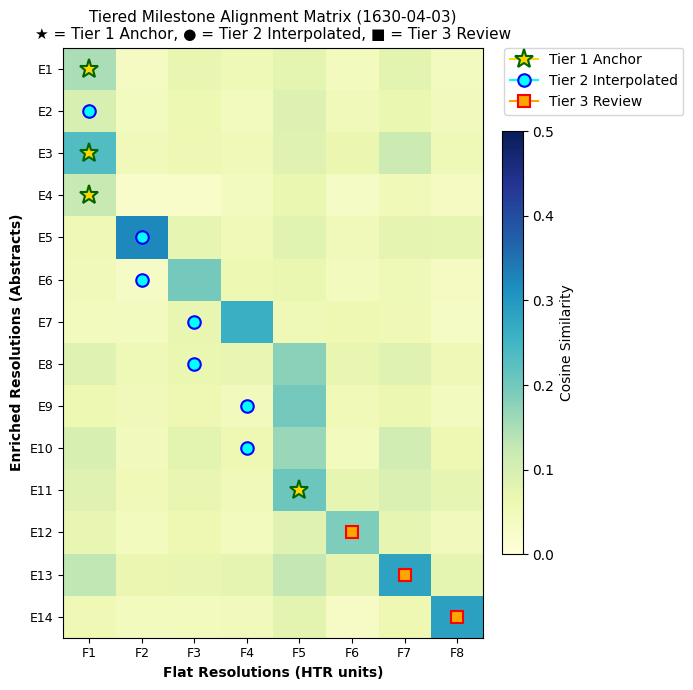

Pair,Enriched Summary,Flat Transcription,Shared Entities,TF-IDF Sim,Overlap Score,Confidence Tier
E1 ↔ F11630-04-03_0session-3189-num-84-resolution-1,Het rapport van Huijgens en andere gedeputeerden van HHM wordt gehoord. Zij hebben conform de resolutie van HHM besprekingen gevoerd met de gedeputeerden van de stad Emden. Enkele gedeputeerden zullen de uitkomst ...,Synde gehoort t' rapport vande heer Huygens ende andere haer Ho:Mo: Gedepden 151. achtervolgens haer ho:Mo: resolutie in conferentie geweest synde met de heeren Gedeputeerden der Stadt Embden. Is nae voorgaende delibera...,Emden,0.149,4.16,Tier 1 (Anchor Milestone)
E2 ↔ F11630-04-03_1session-3189-num-84-resolution-1,De RvS zal de provincies aanschrijven de kapiteins van de vijftig compagnieën die in 1628 op de been zijn gebracht 5 gld. te betalen voor iedere man die door hen ter versterking van hun compagnie wordt aangenomen en 5 st...,Synde gehoort t' rapport vande heer Huygens ende andere haer Ho:Mo: Gedepden 151. achtervolgens haer ho:Mo: resolutie in conferentie geweest synde met de heeren Gedeputeerden der Stadt Embden. Is nae voorgaende delibera...,(none),0.097,0.00,Tier 2 (Merged Page)
E3 ↔ F11630-04-03_2session-3189-num-84-resolution-1,"Schaffer rapporteert conform de resolutie van HHM van 30 maart resident Carlaton thuis te hebben ontboden. Hij heeft hem de inhoud van de resolutie eerst mondeling meegedeeld, en daarna voorgelezen. Carlaton had g...",Synde gehoort t' rapport vande heer Huygens ende andere haer Ho:Mo: Gedepden 151. achtervolgens haer ho:Mo: resolutie in conferentie geweest synde met de heeren Gedeputeerden der Stadt Embden. Is nae voorgaende delibera...,(none),0.233,0.00,Tier 1 (Anchor Milestone)
E4 ↔ F11630-04-03_3session-3189-num-84-resolution-1,President Rantwijck deelt mee dat ambassadeur De Beaugij sterk aandringt op ontslag van het schip van Jan Pissot. HHM zullen zo spoedig mogelijk besluiten in deze zaak.,Synde gehoort t' rapport vande heer Huygens ende andere haer Ho:Mo: Gedepden 151. achtervolgens haer ho:Mo: resolutie in conferentie geweest synde met de heeren Gedeputeerden der Stadt Embden. Is nae voorgaende delibera...,(none),0.122,0.00,Tier 1 (Anchor Milestone)
E5 ↔ F21630-04-03_4session-3189-num-84-resolution-2,"HHM lezen de deductie van Govert Govertsz. Boormaecker over hetgene tussen hem en Evert Roos is voorgevallen betreffende de borgtocht die door Boormaecker was gesteld voor Gerridt Willemsen van Nijeucoop, voormalige...","Synde gelesen sekere deductie van Govert Govertss Boormaecker vant'gene gepasseert is tusschen hem ende Evert Roos noopende de borchtochte byden selven gestelt voor Gerridt, Willemsen van Nieucoop geweest Capn. ter vryer...",(none),0.322,0.00,Tier 2 (Interpolated)
E6 ↔ F21630-04-03_5session-3189-num-84-resolution-2,"Dirck Aelbrechtsz. c.s., voerlieden wonend te Zaltbommel, verzoeken om betaling van 1.413 gld. 14 st. als rest van een groter bedrag aan wagendiensten, door hun in 1627 te velde verricht. HHM verzoeken de RvS t...","Synde gelesen sekere deductie van Govert Govertss Boormaecker vant'gene gepasseert is tusschen hem ende Evert Roos noopende de borchtochte byden selven gestelt voor Gerridt, Willemsen van Nieucoop geweest Capn. ter vryer...",(none),0.033,0.00,Tier 2 (Interpolated)
E7 ↔ F31630-04-03_6session-3189-num-84-resolution-3,"Heijmen Gysbrechsz. wonend te Andel, Arien Meerten c.s. wonend te Aalburg alsmede Adriaen Pauwelsz. c.s., allen opgezetenen van het platteland in het Land van Altena, verzoeken ter bebouwing van hun land enkele pa...",Is gelesen de requeste van dirck Aelbrechs cum socys voerluyden wonende tot Bommel om te hebben betalinge van 1413-14-0. als reste van meerder over ende ter saecke van wagediensten by hun @o. 1627. te verde gedaen. Waero...,(none),0.070,0.00,Tier 2 (Interpolated)
E8 ↔ F31630-04-03_7session-3189-num-84-resolution-3,"Ontvangen is een brief van de burgemeesters, schepenen en de raad van de stad Tiel d.d. Tiel 16 maart. Een groep vijandelijke soldaten van het



=== Date: 1627-07-15 (session(1)) ===
Enriched resolutions: 18 | Flat candidates: 10 (stitched to 7 units)


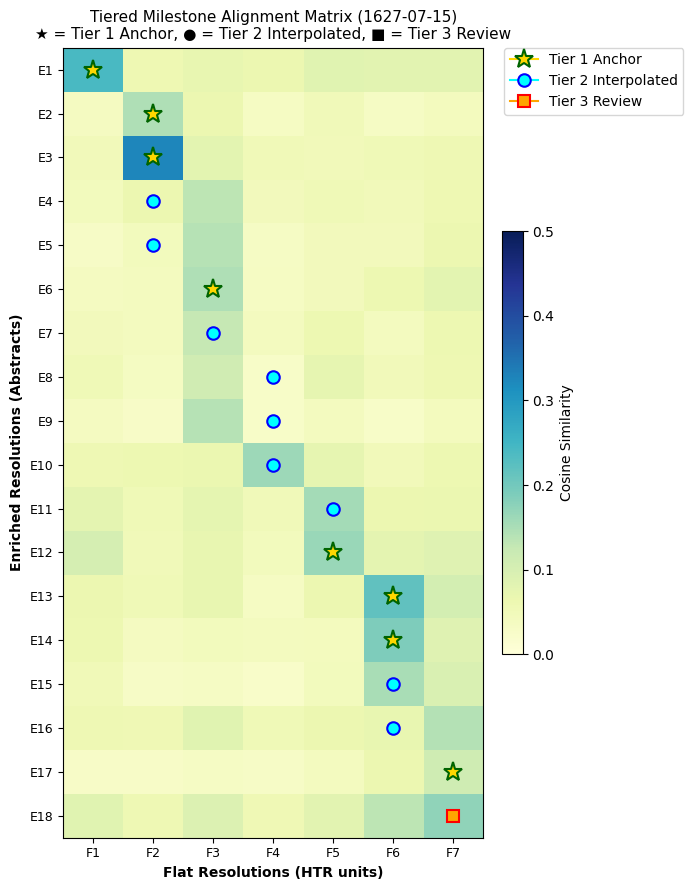

Pair,Enriched Summary,Flat Transcription,Shared Entities,TF-IDF Sim,Overlap Score,Confidence Tier
E1 ↔ F11627-07-15_0session-3186-num-119-resolution-1,Secretaris Huigens dient een brief met enkele stukken in van Veltriel d.d. Emden 29 juni. Hierin meldt deze dat de graaf van Oost-Friesland op 28 juni door die van Emden is ingehuldigd. Hiervan wordt kopie gestuur...,"Walta, Aelberts, Broersema, Synde byden Secretaris Huigens ter Vergaderinge ingelevert seeckere missive byden heer Veltriel uyt Emden geschreven, den xxixen. Juny lestleden, daerby by neffens oversendinge van eenige stuc...","Brussel, Oost-Friesland, Emden",0.241,15.33,Tier 1 (Anchor Milestone)
E2 ↔ F21627-07-15_1session-3186-num-119-resolution-2,"David Vendel mag tegen betaling van 's lands rechten zes musketten, zes spiesen, zeven of acht oude wapenuitrustingen en vier dozijn musketvorken naar Schotland brengen.","Is geaccordeert dat David Vendel naer Schotlant sal mogen brengen ses musquetten, ses spressen, seven off acht oude wapenen off rustingen ende vier dosyn forquet stocken. mits betalende de gerechticheyt vant lant. Is me...",Schotland,0.145,6.77,Tier 1 (Anchor Milestone)
E3 ↔ F21627-07-15_2session-3186-num-119-resolution-2,"De volgende personen is tegen Bosch' licent en onder cautie de uitvoer van paarden toegestaan: Govert Denissen, Hendrick Denissen en Willem Claessen ieder twee merries enJan Aertsen één merrie naar Sprang; Dirck J...","Is geaccordeert dat David Vendel naer Schotlant sal mogen brengen ses musquetten, ses spressen, seven off acht oude wapenen off rustingen ende vier dosyn forquet stocken. mits betalende de gerechticheyt vant lant. Is me...","Heusden, Altena",0.326,11.75,Tier 1 (Anchor Milestone)
E4 ↔ F21627-07-15_3session-3186-num-119-resolution-2,"Over het verzoek van Jan Damen, wonend in Terheijden, materialen voor de opbouw van zijn huis per schip te mogen halen, vragen HHM advies aan de RvS.","Is geaccordeert dat David Vendel naer Schotlant sal mogen brengen ses musquetten, ses spressen, seven off acht oude wapenen off rustingen ende vier dosyn forquet stocken. mits betalende de gerechticheyt vant lant. Is me...",(none),0.064,0.00,Tier 2 (Adjacent)
E5 ↔ F21627-07-15_4session-3186-num-119-resolution-2,"Simon Ghim, koopman in Amsterdam, verzoekt ieder kwartaal voor 4.000 gld. aan laken, karsaaien, baaien en andere stoffen naar Xanten en Bocholt te mogen brengen. HHM vragen hierover advies aan de RvS.","Is geaccordeert dat David Vendel naer Schotlant sal mogen brengen ses musquetten, ses spressen, seven off acht oude wapenen off rustingen ende vier dosyn forquet stocken. mits betalende de gerechticheyt vant lant. Is me...",(none),0.043,0.00,Tier 2 (Adjacent)
E6 ↔ F31627-07-15_5session-3186-num-119-resolution-3+session-3186-num-119-resolution-4+session-3186-num-119-resolution-5[Stitched: 3 parts],"HHM vragen de RvS advies over het verzoek van de Amsterdamse lakenkopers om allerlei soorten wollen laken, karsaaien en andere manufacturen te mogen halen.","Opt versoeck van Jan Damen woonende ter heiden om eenige materialen tot opbouwinge van syn huis te schepe derwaerts te mogen brengen, Is goetgevonden te verstaen het advis des Raedts van State. Gelyck mede derselver adv...",Amsterdam,0.146,3.32,Tier 1 (Anchor Milestone)
E7 ↔ F31627-07-15_6session-3186-num-119-resolution-3+session-3186-num-119-resolution-4+session-3186-num-119-resolution-5[Stitched: 3 parts],"Geraert Thins, burger van Dordrecht, verzoekt gedurende enkele jaren de vrije invoer van honderdduizend pond koper en honderdduizend pond kalmijn, evenals anderen die hier nieuwe fabrieken hebben opgericht. HHM vrag...","Opt versoeck van Jan Damen woonende ter heiden om eenige materialen tot opbouwinge van syn huis te schepe derwaerts te mogen brengen, Is goetgevonden te verstaen het advis des Raedts van State. Gelyck mede derselver adv...",(none),0.127,0.00,Tier 2 (Interpolated)
E8 ↔ F41627-07-15_7session-3186-num-119-resolution-6,HHM laten de RvS adviseren over de verzochte interpre



No flat candidate resolutions found in pool.




In [6]:
sample_dates = random.sample(candidate_dates, 3)
for d in sample_dates:
    inspect_date(d)
    print("\n" + "="*80 + "\n")

## 6. Optional LLM Summary Comparison
This is a small, local-only experiment. It sends at most eight existing labeled pairs to Ollama, asks for structured event summaries of the flat texts, caches the results, and compares the generated summaries with the enriched summaries using the same TF-IDF embedder. It does not run unless the next cell is executed.

In [7]:
import json
import re
import urllib.request
from data_io import save_semi_structured

LLM_CACHE_PATH = ROOT / "output" / "llm_summary_experiment.jsonl"
LLM_MODEL = "llama3.2:latest"
LLM_MAX_PAIRS = 25


def ollama_summary(full_text: str, model: str = LLM_MODEL) -> dict:
    prompt = f"""You are analyzing a 17th-century Dutch Republic resolution.
Extract a compact factual event fingerprint from this HTR text.
Return JSON only with these keys: actors, places, organizations, subject, action, date.
Each value must be a short string; do not invent information. Use an empty string when unknown.

HTR TEXT:
{full_text[:1800]}
"""
    payload = json.dumps({
        "model": model,
        "prompt": prompt,
        "stream": False,
        "format": "json",
        "options": {"temperature": 0.0},
    }).encode("utf-8")
    request = urllib.request.Request(
        "http://localhost:11434/api/generate",
        data=payload,
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    with urllib.request.urlopen(request, timeout=45) as response:
        raw = json.loads(response.read().decode("utf-8")).get("response", "")
    match = re.search(r"\{.*\}", raw, re.DOTALL)
    if not match:
        raise ValueError("Ollama did not return a JSON object")
    parsed = json.loads(match.group(0))
    keys = ["actors", "places", "organizations", "subject", "action", "date"]
    return {key: str(parsed.get(key, "")) for key in keys}


def run_llm_summary_experiment(max_pairs: int = LLM_MAX_PAIRS, seed: int = 9673):
    labeled_path = ROOT / "output" / "ground_truth_labeled.json"
    if not labeled_path.exists():
        print(f"Missing labeled ground truth: {labeled_path}")
        return pd.DataFrame()

    try:
        with urllib.request.urlopen("http://localhost:11434/api/tags", timeout=3) as response:
            if response.status != 200:
                print("Ollama is not available; no calls made.")
                return pd.DataFrame()
    except Exception:
        print("Ollama is not available; no calls made.")
        return pd.DataFrame()

    records = json.loads(labeled_path.read_text(encoding="utf-8"))
    rng = random.Random(seed)
    selected = records.copy()
    rng.shuffle(selected)
    selected = selected[:max_pairs]
    cached = {}
    if LLM_CACHE_PATH.exists():
        cached = {
            row["pair_key"]: row
            for row in (json.loads(line) for line in LLM_CACHE_PATH.read_text(encoding="utf-8").splitlines() if line.strip())
        }

    enriched_by_id = {enriched_volgnr(item): item for item in enriched_all if enriched_volgnr(item)}
    output_rows = []
    for record in selected:
        pair_key = f"{record['enriched_id']}::{record['flat_id']}"
        if pair_key in cached:
            result = cached[pair_key]
        else:
            enriched_record = enriched_by_id.get(record["enriched_id"])
            flat_record = res_df[res_df["id"].astype(str) == str(record["flat_id"])]
            if enriched_record is None or flat_record.empty:
                continue
            try:
                fingerprint = ollama_summary(candidate_text(flat_record.iloc[0]))
            except Exception as error:
                print(f"Skipping {pair_key}: {error}")
                continue
            generated_text = " | ".join(f"{key}: {value}" for key, value in fingerprint.items() if value)
            enriched_summary = enriched_text(enriched_record)
            score = float(embedder.compute_similarity_matrix([enriched_summary], [generated_text])[0, 0])
            result = {
                "pair_key": pair_key,
                "enriched_id": record["enriched_id"],
                "flat_id": record["flat_id"],
                "verdict": record.get("verdict"),
                "tfidf_summary_score": score,
                "fingerprint": fingerprint,
            }
            cached[pair_key] = result
            save_semi_structured(
                list(cached.values()),
                out_path=LLM_CACHE_PATH,
                parent_sources=["resolutions_flat", "ground_truth_labeled"],
                description="Cached local LLM event fingerprints for labeled resolution alignment experiments.",
                script="notebooks/alignment_inspection.ipynb",
            )
        output_rows.append(result)

    result_df = pd.DataFrame(output_rows)
    if result_df.empty:
        print("No experiment rows were produced.")
        return result_df
    display(result_df[["enriched_id", "flat_id", "verdict", "tfidf_summary_score"]])
    print("Mean TF-IDF summary score by manual verdict:")
    display(result_df.groupby("verdict")["tfidf_summary_score"].agg(["count", "mean", "median"]))
    print(f"Cached LLM fingerprints: {LLM_CACHE_PATH}")
    return result_df

# Opt-in: this makes local Ollama calls and costs time, but no external API calls.
llm_experiment = run_llm_summary_experiment()

,enriched_id,flat_id,verdict,tfidf_summary_score
0,1626-10-06_2,session-3185-num-160-resolution-25,false_positive,0.076074
1,1628-11-06_7,session-3187-num-258-resolution-4,correct,0.048748
2,1629-09-08_9,session-3188-num-206-resolution-2,correct,0.087519
3,1627-08-08_0,session-3186-num-131-resolution-1,correct,0.135316
4,1628-03-28_8,session-3187-num-84-resolution-5,correct,0.093841
5,1630-02-20_11,session-3189-num-45-resolution-6,false_positive,0.027994
6,1629-05-05_9,session-3188-num-118-resolution-7,false_positive,0.129628
7,1629-01-13_0,session-3188-num-13-resolution-1,correct,0.109724
8,1627-02-16_2,session-3186-num-29-resolution-2,correct,0.094109
9,1626-08-06_9,session-3185-num-127-resolution-6,correct,0.147583


Mean TF-IDF summary score by manual verdict:


,count,mean,median
verdict,,,
correct,13,0.100584,0.109724
false_positive,12,0.073128,0.078048


Cached LLM fingerprints: /Users/rikhoekstra/develop/republic_ner_matching/output/llm_summary_experiment.jsonl
